In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
# Ignoring all future warnings
warnings.filterwarnings('ignore', category = FutureWarning)

In [2]:
data = pd.read_csv("train.csv")
data.sample(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
126,127,120,RL,NaN,4928,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2007,WD,Normal,128000
904,905,20,RL,NaN,6173,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,8,2007,WD,Normal,125500
1352,1353,50,RM,50.0,6000,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,134900
296,297,50,RM,75.0,13710,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal,152000
482,483,70,RM,50.0,2500,Pave,Pave,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,155000


In [3]:
cat_cols = data.select_dtypes(["object"]).columns
cat_cols, len(cat_cols)

(Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
        'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
        'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
        'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
        'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
        'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
        'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
        'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
        'SaleType', 'SaleCondition'],
       dtype='object'),
 43)

In [4]:
data["SalePrice"] = np.log(data["SalePrice"])

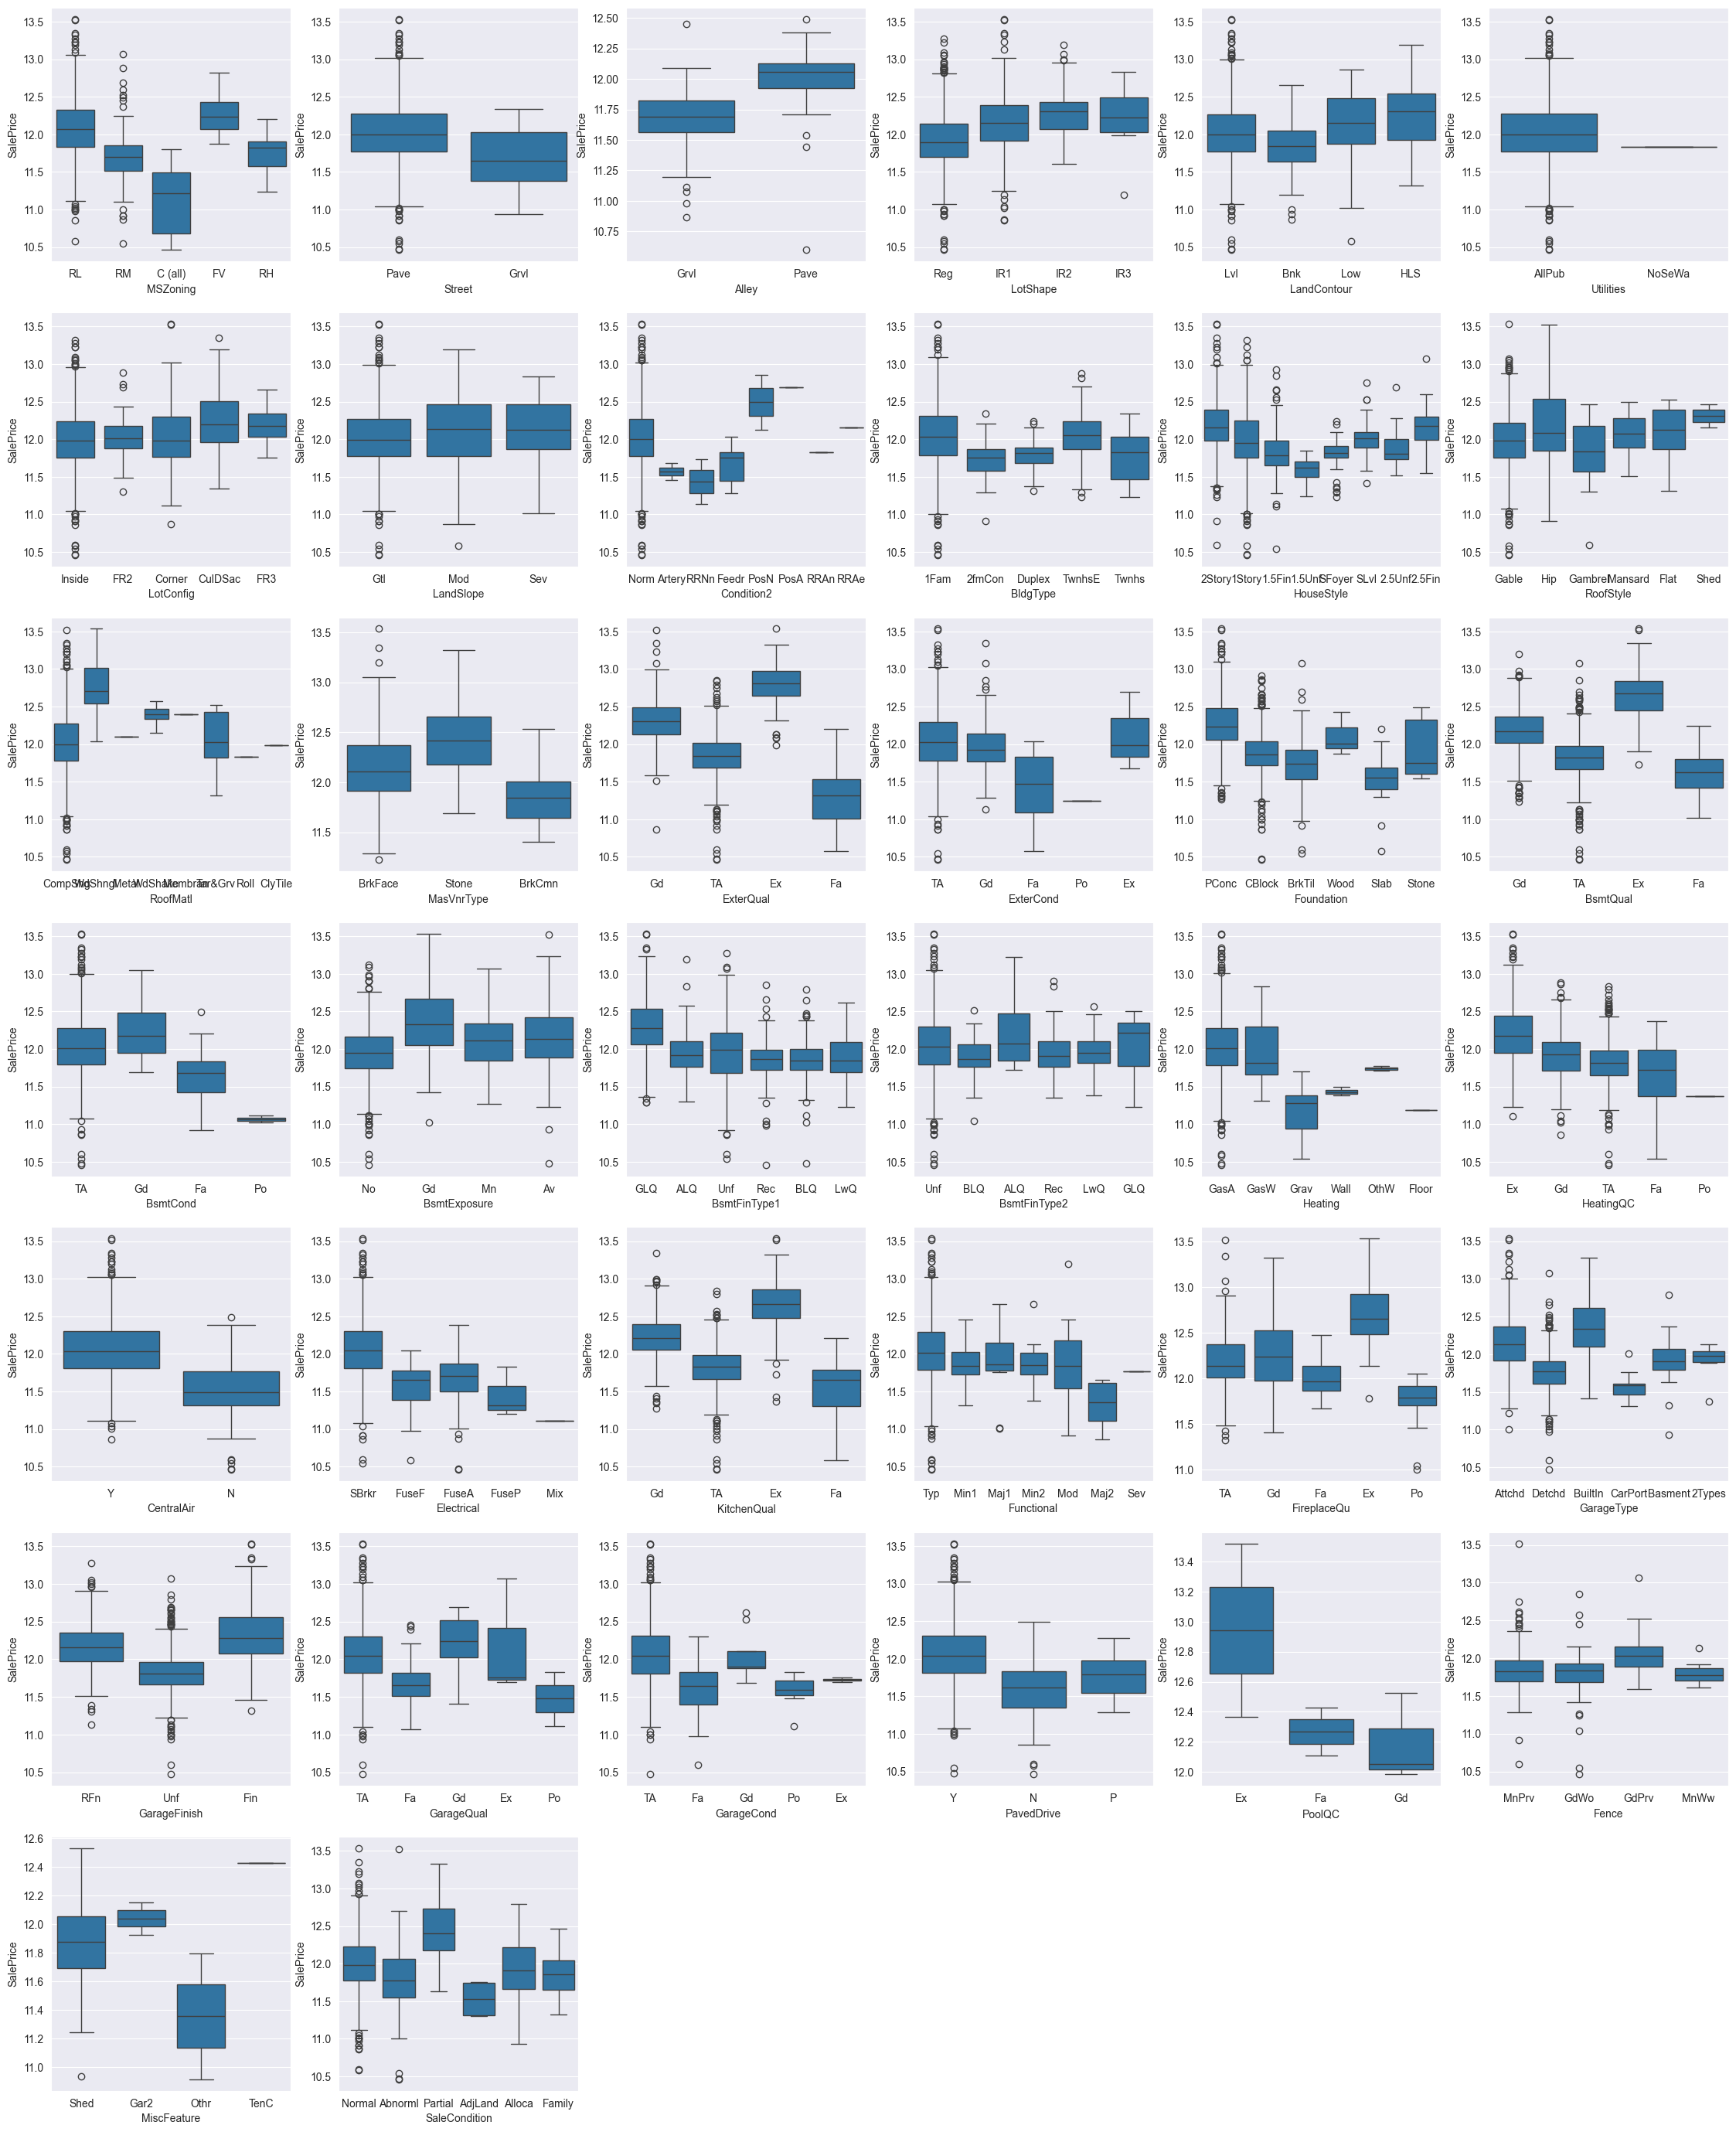

In [5]:

cat_cols = [col for col in cat_cols if len(data[col].unique())<=8]

n = len(cat_cols)

fig, axes = plt.subplots(7,int(len(cat_cols)/7+1), figsize = (28,35))

axes = axes.flatten()

for cat in range(len(axes)):
    if cat >= len(cat_cols):
        axes[cat].set_visible(False)
        continue
    sns.boxplot(x = cat_cols[cat], y = "SalePrice", data = data, ax = axes[cat])



<Axes: >

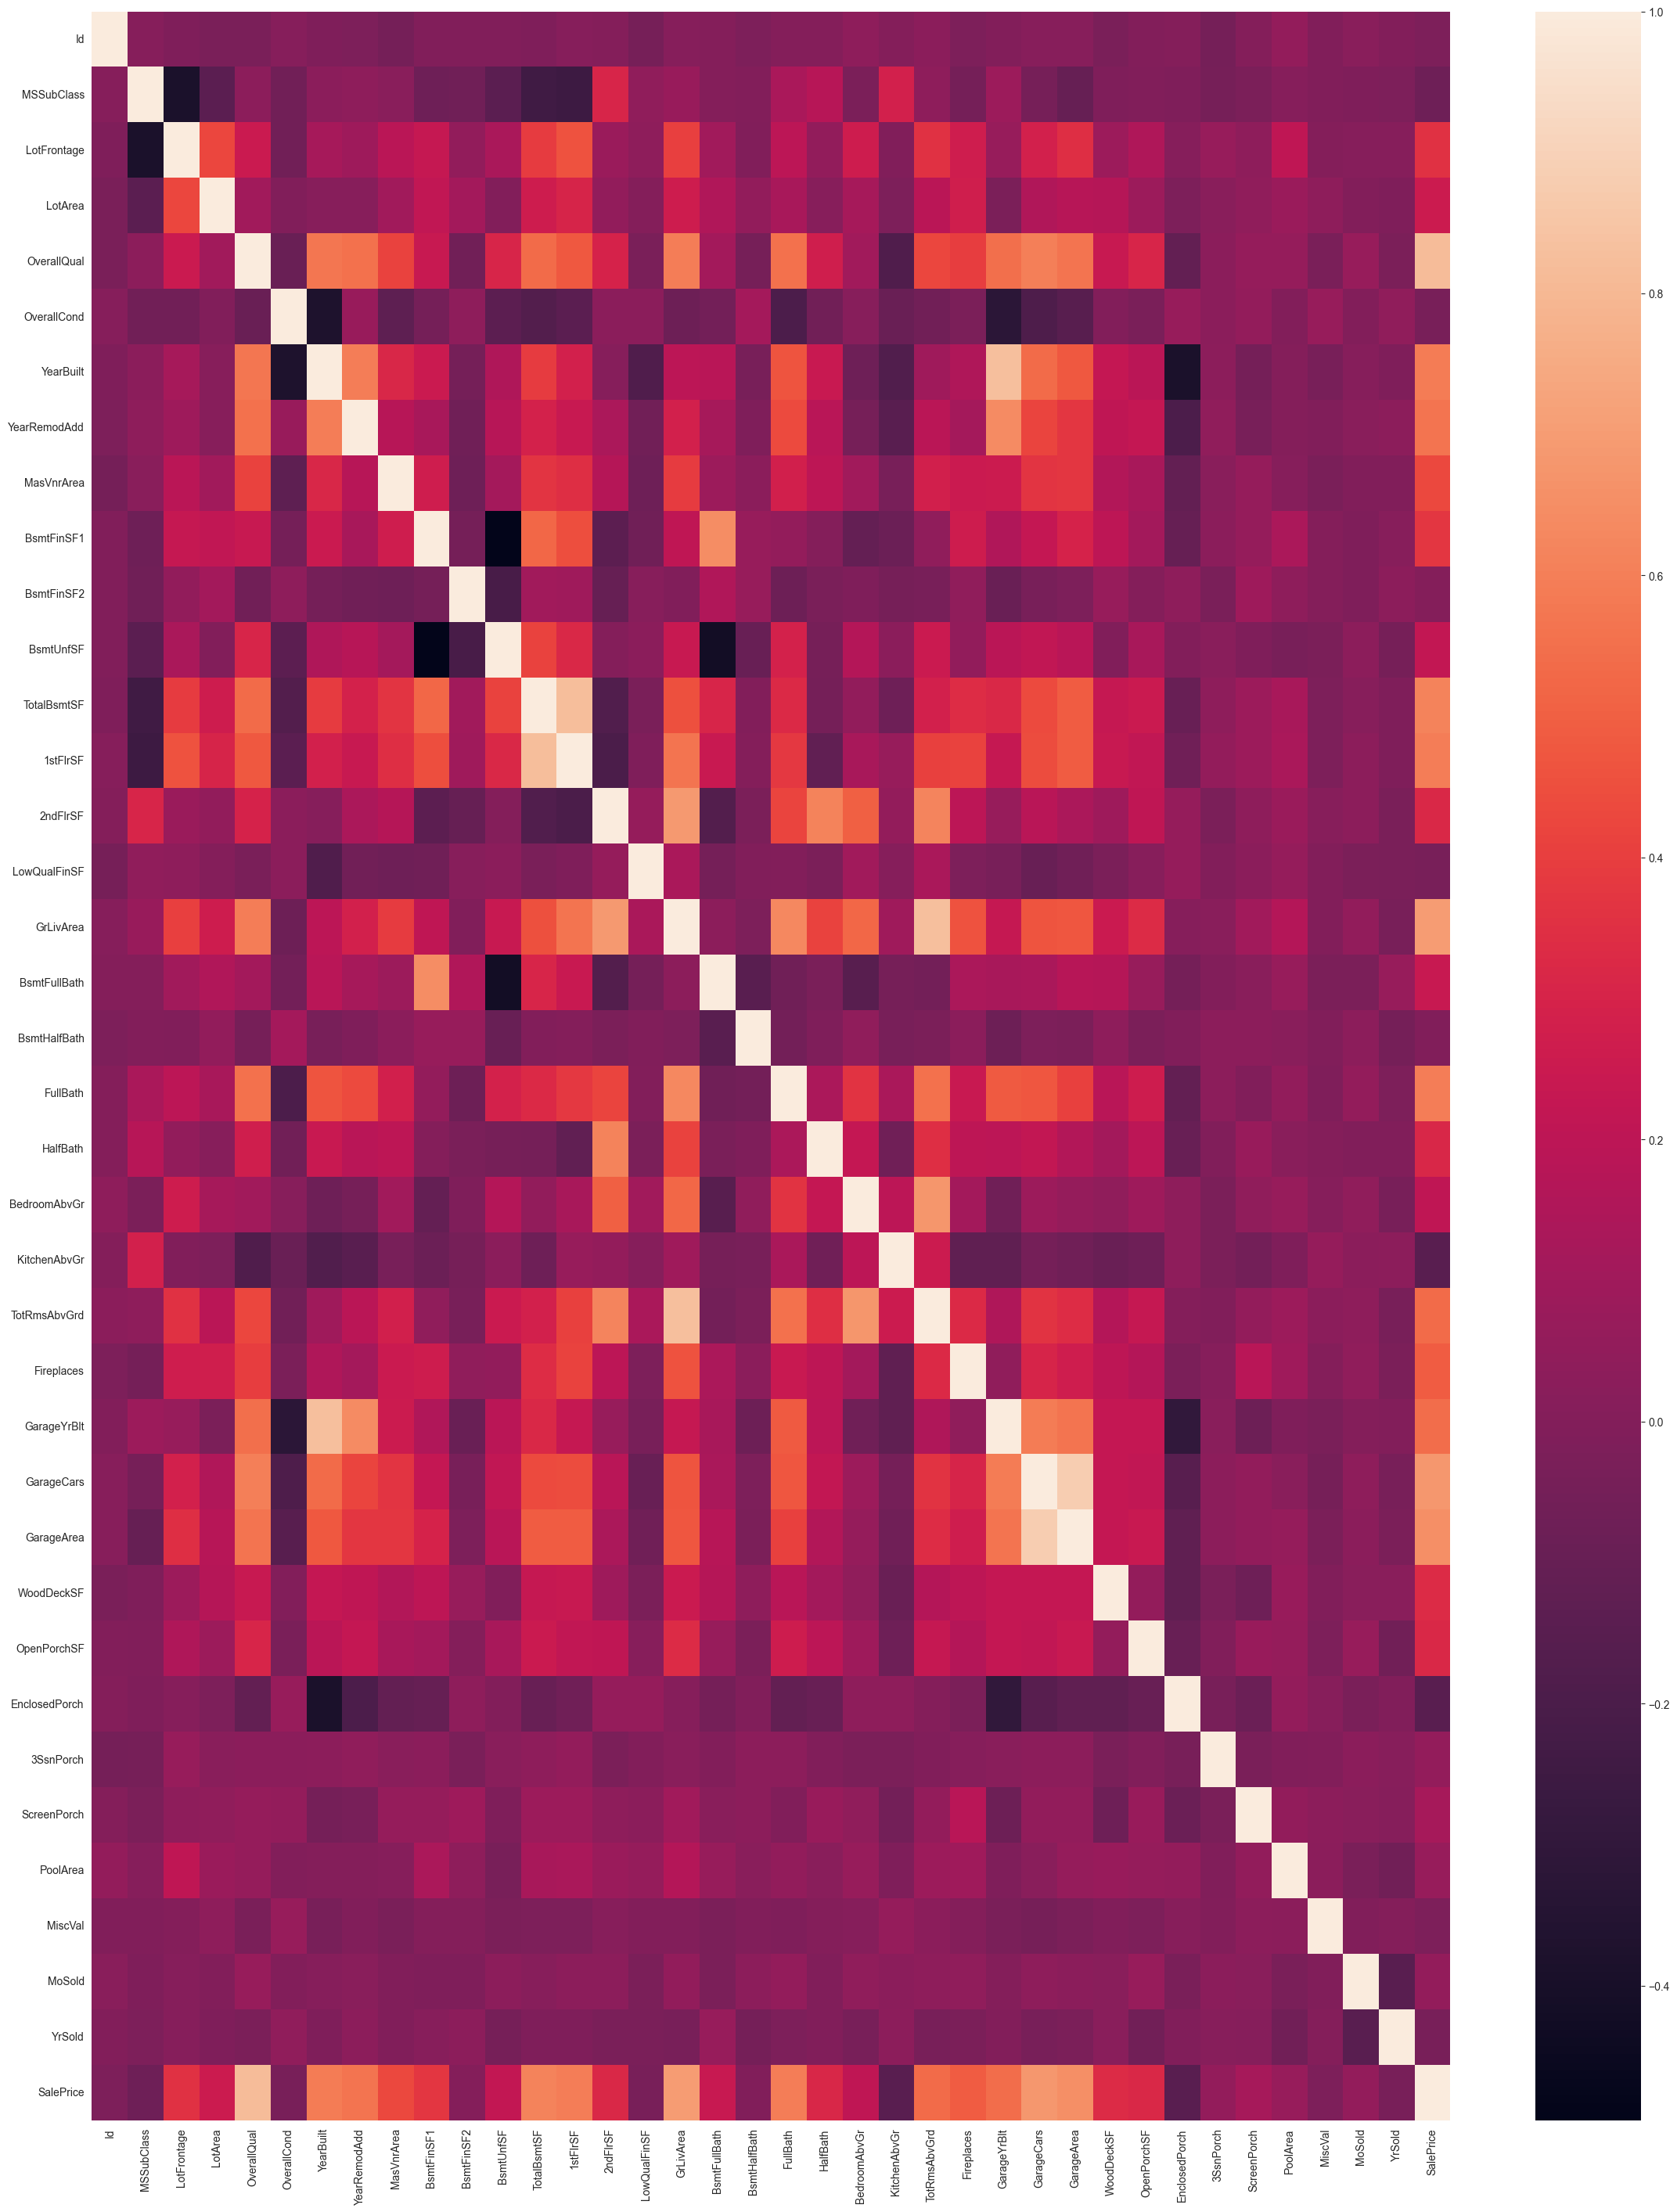

In [6]:
plt.figure(figsize = (28,35))
sns.heatmap(data = data.select_dtypes(exclude = ["object"]).corr("pearson"))

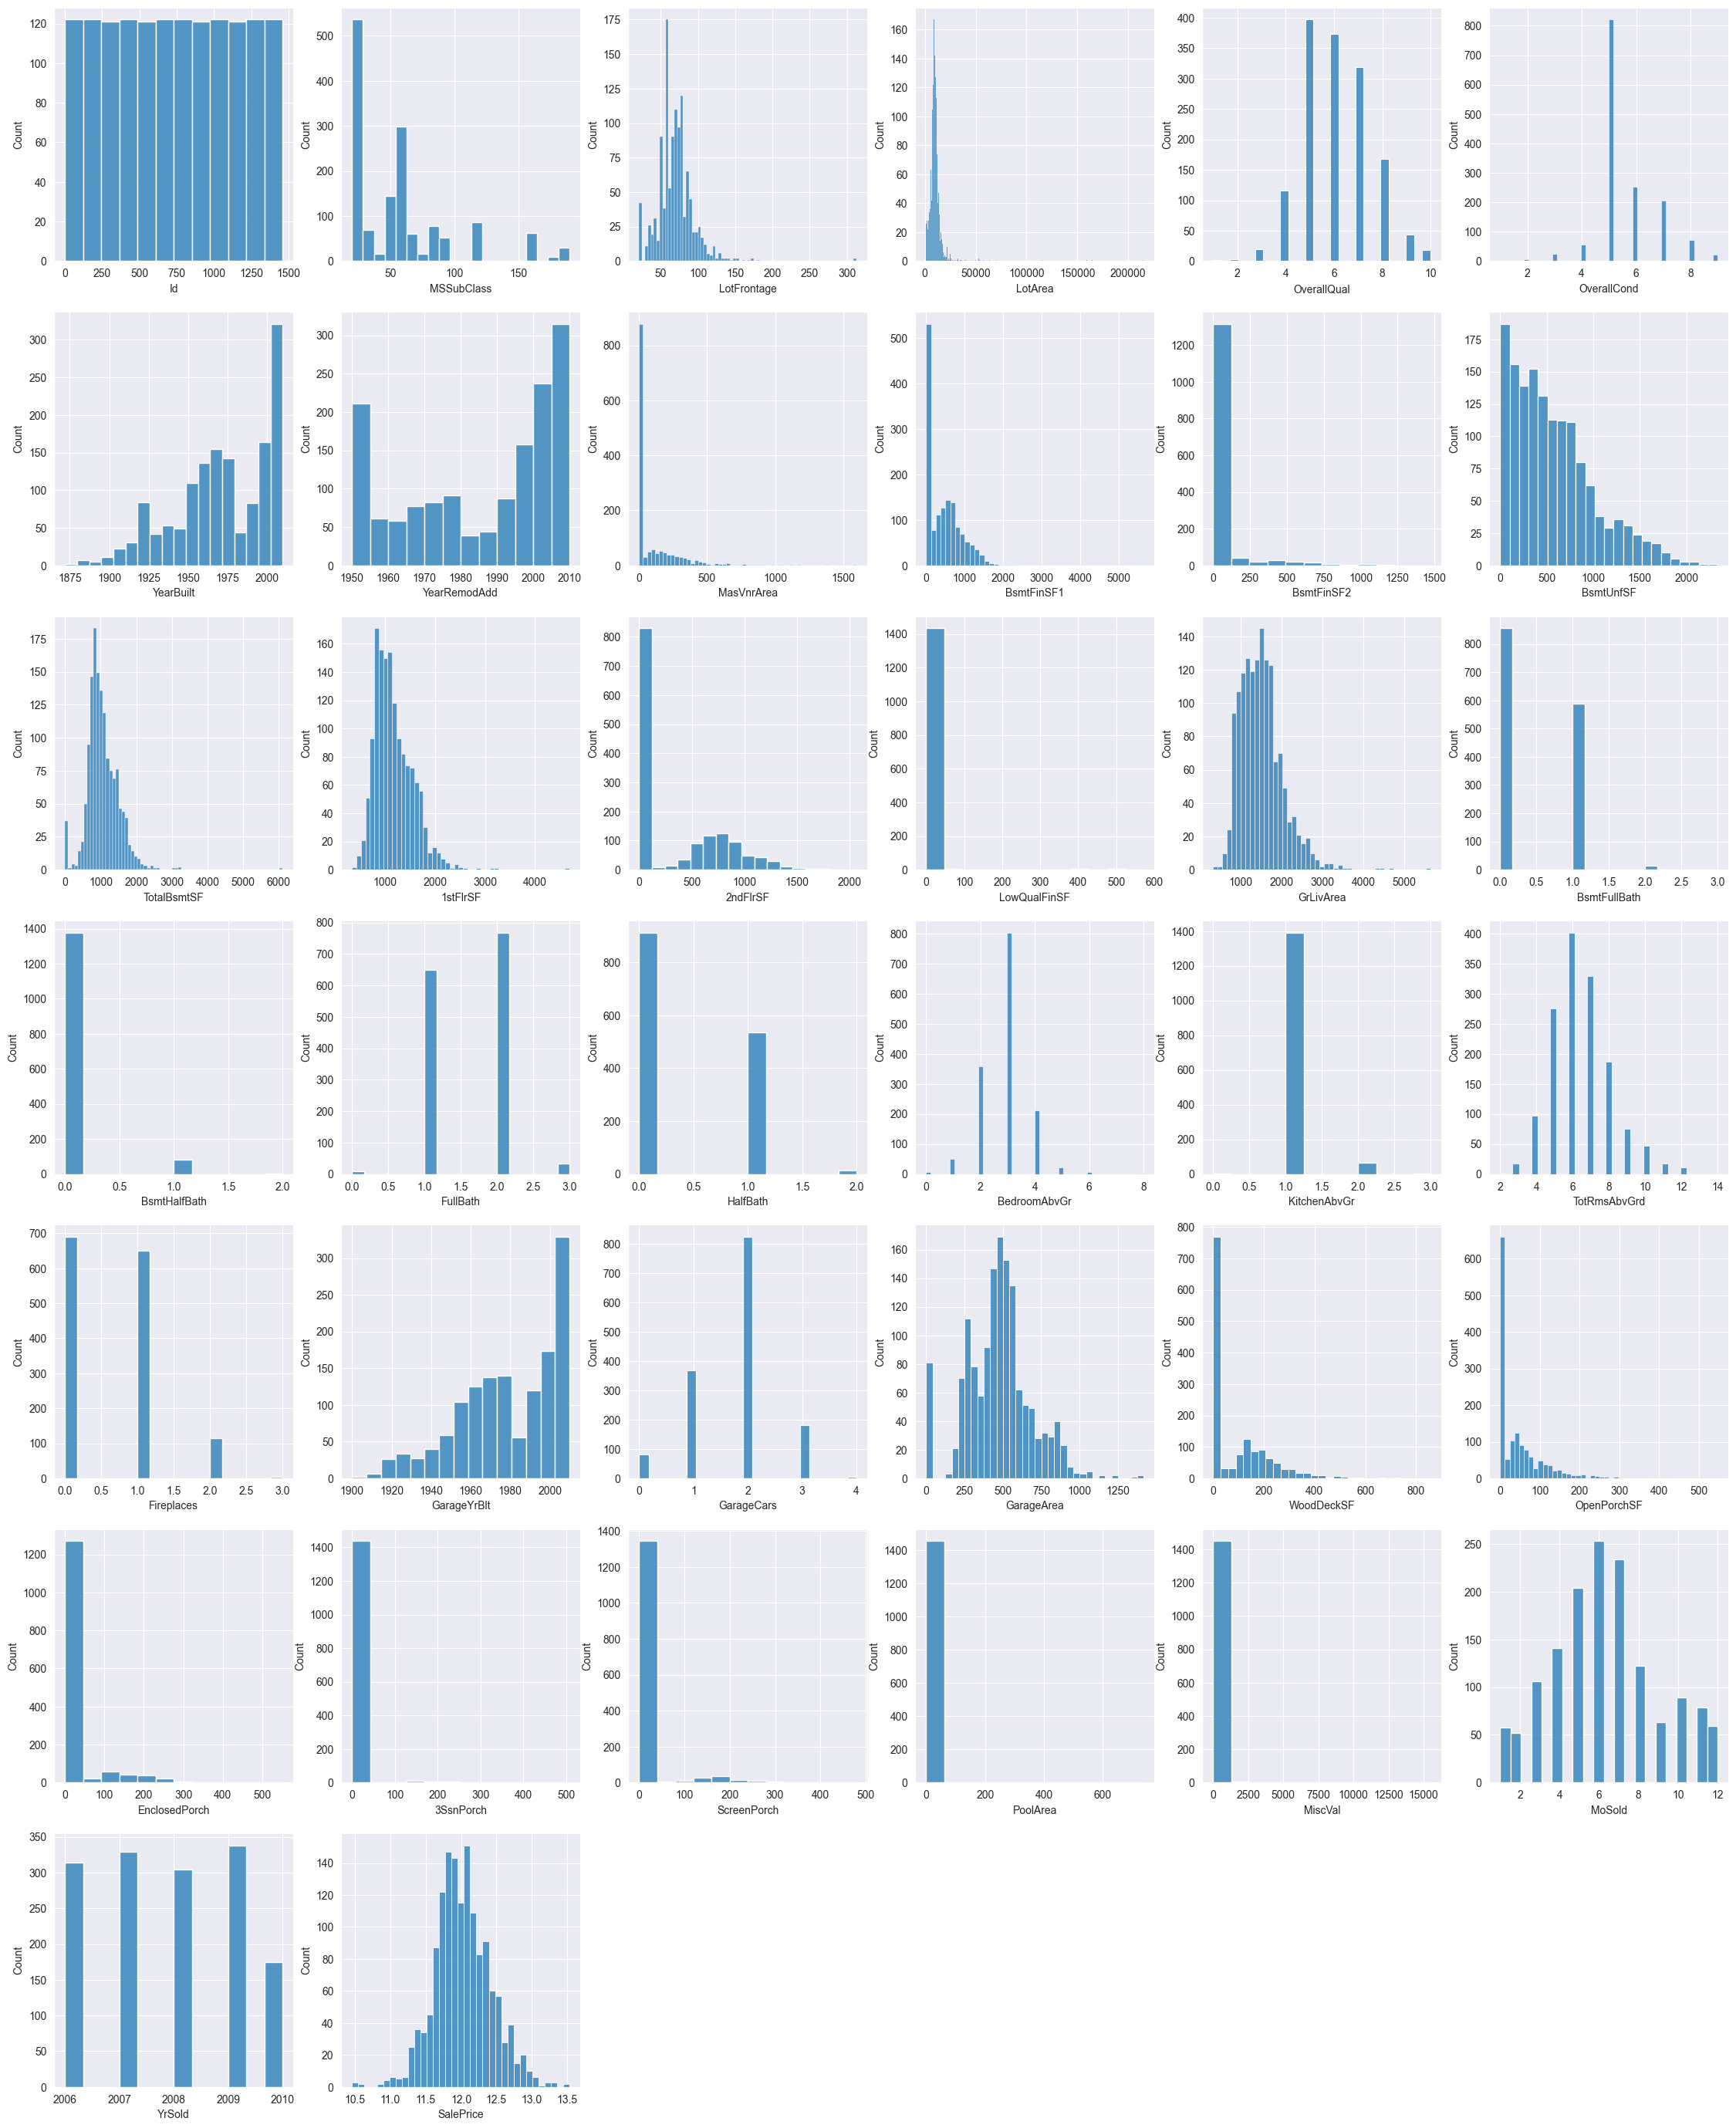

In [8]:
num_cols = data.select_dtypes(exclude = "object").columns
fig, axes = plt.subplots(7,int(len(num_cols)/7+1), figsize = (28,35))

axes = axes.flatten()

for cat in range(len(axes)):
    if cat >= len(num_cols):
        axes[cat].set_visible(False)
        continue
    sns.histplot(x = num_cols[cat],  data = data, ax = axes[cat])